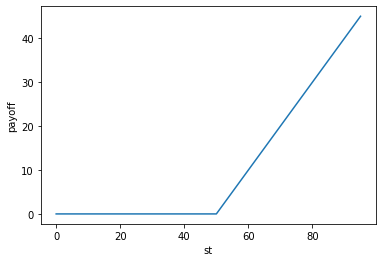

In [ ]:
#看涨期权的到期收益率 股价st高于行权价x盈利，否则不行使权力，max(st−x,0)，max(a,0)=（a+∣a∣​）/2 
def payoff_calls(st,x):
    return (st-x+abs(st-x))/2
#绘制看涨期权图像
import numpy as np
import matplotlib.pyplot as plt
st=np.arange(0,100,5)
x=50
payoff=payoff_calls(st, x)
plt.plot(st,payoff)
plt.xlabel('st')
plt.ylabel('payoff')
plt.show()
#payoff不是最终利润，还要付期权费，最终利润=payoff-c


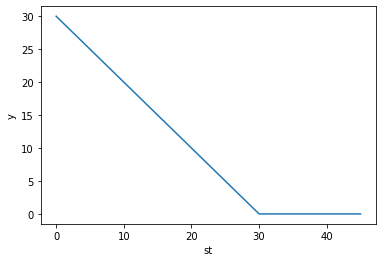

In [5]:
#看跌期权 max(X−ST​,0)
def payoff_put(st,x):
    return (abs(x-st)+x-st)/2

st=np.arange(0,50,5)
x=30
y=payoff_put(st, x)
plt.plot(st,y)
plt.xlabel('st')
plt.ylabel('y')
plt.show()

In [ ]:
#Black-Scholes（BS）期权定价模型
from scipy import stats
from math import log,exp,sqrt
#call C=SN(d1​)−Xe**（−rt）N(d2​) s当前股价，x行权价，t到期时间，r无风险利率，sigma波动率
def bs_call(s,x,t,r,sigma):
    d1=(log(s/x)+(r+sigma*sigma/2)*t)/(sigma*sqrt(t))
    d2=d1-sigma*sqrt(t)
    c=s*stats.norm.cdf(d1)-x*exp(-r*t)*stats.norm.cdf(d2)
    return c
print(bs_call(30, 40, 0.5, 0.01, 0.2))

#put P=Xe**（−rt）N(−d2​)−SN(−d1​)
def bs_put(s,x,t,r,sigma):
    d1=(log(s/x)+(r+sigma*sigma/2)*t)/(sigma*sqrt(t))
    d2=d1-sigma*sqrt(t)
    p=x*exp(-r*t)*stats.norm.cdf(-d2)-s*stats.norm.cdf(-d1)
    return p
print(bs_call(30, 40, 0.5, 0.01, 0.2))

0.04153665815537744
0.04153665815537744


In [6]:
#隐含波动率（Implied Volatility） 已知股票价格s和市场期权价格c，求波动率sigma
from math import log,exp,sqrt
from scipy import stats
def implied_vol_call(s,x,t,r,c):
    for i in range(200):
        sigma=0.005*(i+1)
        d1=(log(s/x)+(r+sigma*sigma/2)*t)/(sigma*sqrt(t))
        d2=d1-sigma*sqrt(t)
        diff=s*stats.norm.cdf(d1)-x*exp(-r*t)*stats.norm.cdf(d2)-c
        if abs(diff)<0.1:
            return sigma
print(implied_vol_call(30, 40, 0.5, 0.01, 0.5)) 

def implied_vol_put(s,x,t,r,p):
    for i in range(200):
        sigma=0.005*(i+1)
        d1=(log(s/x)+(r+sigma*sigma/2)*t)/(sigma*sqrt(t))
        d2=d1-sigma*sqrt(t)
        diff=x*exp(-r*t)*stats.norm.cdf(-d2)-s*stats.norm.cdf(-d1)-p
        if abs(diff)<0.1:
            return sigma
print(implied_vol_put(30, 40, 0.5, 0.01, 0.5))

0.325
None


In [3]:
#利用“利率平价（Interest Rate Parity）”进行外汇远期套利/对冲 的过程。
#三个月之后要还1个外币，，即期汇率，本币利率，外币利率，时间
from math import exp
obligationforeign=1.0
#市场远期汇率
f=1.26
#即期汇率
s=1.25     
#本币利率
r_domestic=0.01
#外币利率
r_foreign=0.02
#时间
t=3/12
#今天需要准备多少外币，才能在三个月后变成 1 单位外币
todayobligationforeign=obligationforeign*exp(-r_foreign*t)
#今天需要准备多少本币，才能等于三个月后需要准备的外币
usborrow=todayobligationforeign*s
#借了三个月的本币产生的利息interest
costdollarborrow=usborrow*exp(r_domestic*t)
profit=costdollarborrow-obligationforeign*f
print(profit)


-0.013121097003174764


In [5]:
#如何用 Python 计算欧式看涨期权（Call Option）的 Delta：股票上涨一元，期权价格上涨多少
from math import log,exp,sqrt
from scipy import stats
def bscall(s,x,t,r,sigma):
    d1=(log(s/x)+(r+sigma*sigma/2)*t)/(sigma*sqrt(t))
    d2=d1-sigma*sqrt(t)
    return s*stats.norm.cdf(d1)-x*exp(-r*t)*stats.norm.cdf(d2)
tiny=1e-11
s=40;x=40;t=0.5;r=0.01;sigma=0.2  
#法一：解析公式计算
def delta_f(s,x,t,r,sigma):
    d1=(log(s/x)+(r+sigma*sigma/2)*t)/(sigma*sqrt(t))
    delta=stats.norm.cdf(d1)
    return delta
#法二：数值微分计算
def delta_n(s,x,t,r,sigma):
    c1=bscall(s,x,t,r,sigma)
    c2=bscall(s+tiny,x,t,r,sigma)
    delta=(c2-c1)/tiny
    return delta
print(delta_f(s,x,t,r,sigma))
print(delta_n(s,x,t,r,sigma))   


0.5422350133116141
0.5421441073849564
